# 2D full-field sarcomere tracking

Automated tracking of every sarcomere vector across the whole image — the complement to the 1D LOI method (`tutorial_motion_analysis.ipynb`). Results are stored as dense `(n_tracks, T)` arrays in `sarc.data`.

Details: [API reference](../autoapi/sarcasm/structure_modules/sarcomere_tracking/index.html).

In [1]:
from sarcasm import *
import matplotlib.pyplot as plt
import numpy as np

## Detection

Run the sarcomere U-Net on the movie (same upstream step as the structural and LOI tutorials). We also run the **3D U-Net fast-movie Z-band model** — it emits Z-band masks that are ~3× less noisy frame-to-frame than the per-frame 2D output and is used automatically by `analyze_sarcomere_vectors` when available.

In [2]:
file_path = '../../test_data/high_speed_single_ACTN2-citrine_CM/20kPa.tif'
sarc = Structure(file_path)
frames = list(range(100))  # use 'all' for the full movie

2026-04-24 17:01:46 - sarcasm.utils - INFO - Using device: mps


In [3]:
sarc.detect_sarcomeres(frames=frames)
sarc.detect_z_bands_fast_movie()  # 3D U-Net — optional but recommended

2026-04-24 17:01:47 - sarcasm.structure_modules.detection - INFO - Predicting sarcomeres ...


2026-04-24 17:01:47 - sarcasm.structure_modules.detection - WARNING - Pixel size (0.061 µm) is smaller than the optimal range (0.1-0.35 µm) for generalist model. Pixelsize might be too small. Consider increasing rescale_factor for optimal results.


2026-04-24 17:01:47 - sarcasm.structure_modules.detection - INFO - Using default model: /Users/daniel/Code/SarcAsM/sarcasm/models/model_sarcomeres_generalist.pt


  0%|          | 0/100 [00:00<?, ?it/s]

  1%|          | 1/100 [00:00<00:19,  5.17it/s]

...

 97%|█████████▋| 87/90 [01:06<00:02,  1.33it/s]

 98%|█████████▊| 88/90 [01:07<00:01,  1.33it/s]

 99%|█████████▉| 89/90 [01:08<00:00,  1.33it/s]

100%|██████████| 90/90 [01:09<00:00,  1.33it/s]

100%|██████████| 90/90 [01:09<00:00,  1.30it/s]

## Sarcomere vectors

`peak_algorithm='loi'` uses the same peak-detection pipeline as the LOI analysis (6× Akima + prominence 0.5 + COM refinement) — maximum per-frame slen accuracy. `smooth_orientation_sigma` applies an axial-correct temporal Gaussian to the orientation field.

`use_fast_movie_zbands=True` (the default) reads from `zbands_fast_movie.tif` when it exists. The log line printed by this cell tells you which Z-band source was used; set `use_fast_movie_zbands=False` to force the per-frame 2D masks if the 3D model is unreliable on a given movie.

In [4]:
sarc.analyze_sarcomere_vectors(
    frames=frames,
    linewidth=0.65,
    peak_algorithm='loi',
    smooth_orientation_sigma=1.5,
)

2026-04-24 17:03:17 - sarcasm.structure - INFO - analyze_sarcomere_vectors: using 3D U-Net Z-bands (zbands_fast_movie.tif) — temporally consistent, recommended for smoother per-frame slen.


2026-04-24 17:03:17 - sarcasm.structure - INFO - Temporally smoothing orientation field with sigma=1.50 frames...


2026-04-24 17:03:18 - sarcasm.structure - INFO - Starting sarcomere length and orientation analysis...


  0%|          | 0/100 [00:00<?, ?it/s]

  1%|          | 1/100 [00:02<03:22,  2.05s/it]

...

 97%|█████████▋| 97/100 [01:16<00:02,  1.27it/s]

 98%|█████████▊| 98/100 [01:17<00:01,  1.27it/s]

 99%|█████████▉| 99/100 [01:18<00:00,  1.27it/s]

100%|██████████| 100/100 [01:19<00:00,  1.27it/s]

100%|██████████| 100/100 [01:19<00:00,  1.26it/s]

## 2D tracker
Flow-advects each sarcomere query point and snaps it to the nearest consistent detection every frame. See docstring for all parameters.

In [5]:
sarc.track_sarcomere_vectors(frames=frames)

2026-04-24 17:04:38 - sarcasm.structure - INFO - Tracking 100 frames...


2026-04-24 17:04:38 - sarcasm.structure_modules.sarcomere_tracking - INFO - Computing optical flow sequence…


2026-04-24 17:04:45 - sarcasm.structure_modules.sarcomere_tracking - INFO - Seeding query points from frame 0…


2026-04-24 17:04:45 - sarcasm.structure_modules.sarcomere_tracking - INFO - Tracking frames…


2026-04-24 17:05:50 - sarcasm.structure_modules.sarcomere_tracking - INFO - Filtering short tracks…


2026-04-24 17:05:51 - sarcasm.structure - INFO - Tracked 6350 sarcomere query points over 100 frames.


## Inspect results
Outputs live in `sarc.data`: `tracks_slen`, `tracks_positions_um`, `tracks_positions_px`, `tracks_orientations`, `tracks_snapped`, and the motion-field decomposition (`displacement_along_sarcomere`, `displacement_perpendicular`, `velocity_magnitude`).

In [6]:
slen = np.asarray(sarc.data['tracks_slen'])           # (n_tracks, T)
pos = np.asarray(sarc.data['tracks_positions_um'])     # (n_tracks, T, 2)
snapped = np.asarray(sarc.data['tracks_snapped']).astype(bool)
T = slen.shape[1]
time_s = np.arange(T) * sarc.metadata.frametime
cov = snapped.sum(axis=1) / T
print(f"{slen.shape[0]} tracks; {(cov >= 0.8).sum()} with ≥80% coverage")

6350 tracks; 3138 with ≥80% coverage


### Ensemble sarcomere length

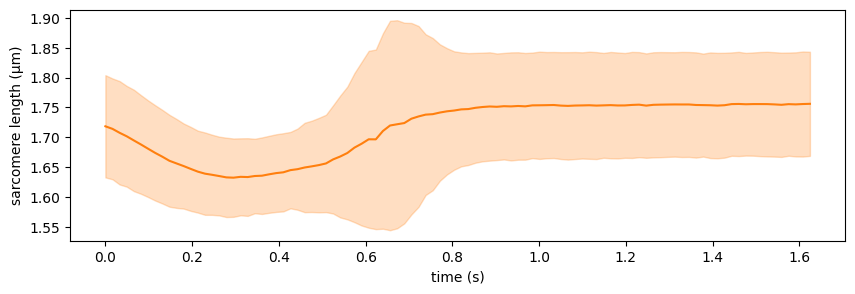

In [7]:
ok = cov >= 0.8
mean = np.nanmean(slen[ok], axis=0)
std = np.nanstd(slen[ok], axis=0)
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(time_s, mean, color='C1')
ax.fill_between(time_s, mean - std, mean + std, alpha=0.25, color='C1')
ax.set_xlabel('time (s)'); ax.set_ylabel('sarcomere length (µm)')
plt.show()

### Sample individual trajectories

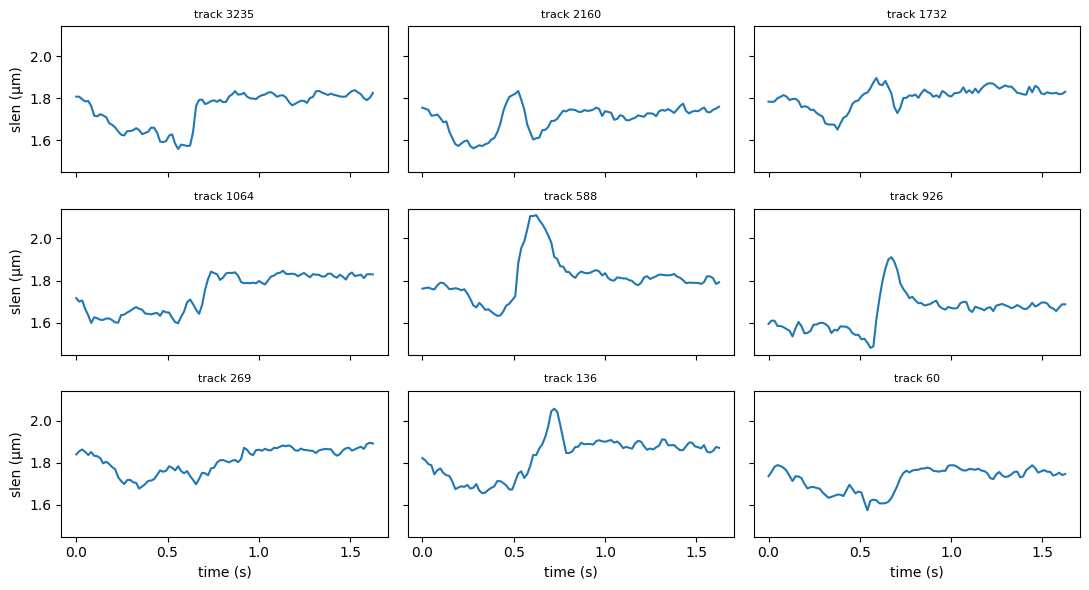

In [8]:
rng = np.random.default_rng(0)
picks = rng.choice(np.where(cov >= 0.95)[0], 9, replace=False)
fig, axes = plt.subplots(3, 3, figsize=(11, 6), sharex=True, sharey=True)
for ax, i in zip(axes.flat, picks):
    ax.plot(time_s, slen[i])
    ax.set_title(f'track {int(sarc.data["track_ids"][i])}', fontsize=8)
for ax in axes[-1]: ax.set_xlabel('time (s)')
for ax in axes[:, 0]: ax.set_ylabel('slen (µm)')
plt.tight_layout(); plt.show()

### Displacement from origin

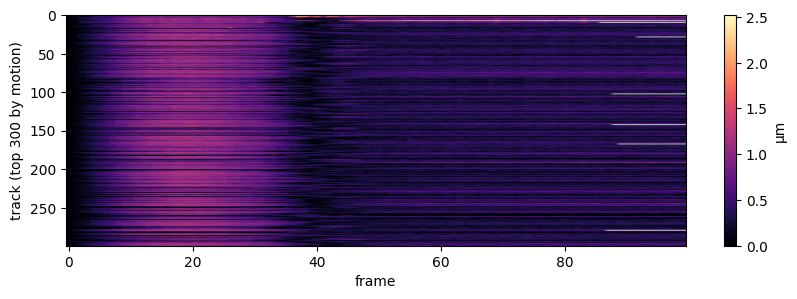

In [9]:
disp = np.linalg.norm(pos - pos[:, :1, :], axis=-1)  # (n_tracks, T)
top = np.argsort(-np.nansum(np.abs(np.diff(disp, axis=1)), axis=1))[:300]
fig, ax = plt.subplots(figsize=(10, 3))
im = ax.imshow(disp[top], aspect='auto', cmap='magma')
ax.set_xlabel('frame'); ax.set_ylabel('track (top 300 by motion)')
fig.colorbar(im, ax=ax, label='µm')
plt.show()

## Motion field without tracking
`Structure.compute_motion_field` computes the flow + per-frame along/perp decomposition only (no tracking). Same `displacement_*` / `velocity_magnitude` outputs as the tracker.

In [10]:
# sarc.compute_motion_field(frames=frames)

## See also
* [`tutorial_motion_analysis.ipynb`](tutorial_motion_analysis.ipynb) — LOI (1D) method
* [`tutorial_structure_analysis.ipynb`](tutorial_structure_analysis.ipynb) — upstream detection
* [`docs/development_sarcomere_tracking.md`](../development_sarcomere_tracking.md) — algorithm details